In [1]:
import pandas as pd
import numpy as np
import joblib
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v2_feas.csv')

In [3]:
# Define which columns are numerical
num_cols_to_fill = ['transaction_amount', 'time_day', 'time_diff_log']

# Fill numerical columns with median
for col in num_cols_to_fill:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# For categorical columns: convert NaN to string 'nan' so it acts as a category
cat_cols_to_fill = [col for col in df.columns if col not in num_cols_to_fill]
for col in cat_cols_to_fill:
    df[col] = df[col].astype(str)  # This converts NaN to string 'nan'

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   is_fraud                 588912 non-null  object 
 1   transaction_amount       588912 non-null  float64
 2   card_type                588912 non-null  object 
 3   purchaser_email_domain   588912 non-null  object 
 4   device_type              588912 non-null  object 
 5   is_identity_seen_before  588912 non-null  object 
 6   user_os                  588912 non-null  object 
 7   user_browser             588912 non-null  object 
 8   environment_risk         588912 non-null  object 
 9   card_info                588912 non-null  object 
 10  time_hour                588912 non-null  object 
 11  time_day                 588912 non-null  float64
 12  amt_bins                 588912 non-null  object 
 13  day_of_week              588912 non-null  object 
 14  time

In [5]:
df = df.drop(columns = ['transaction_amount', 'time_day'], axis= 1)

In [6]:
v4 = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v4.csv')
v4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   is_fraud                 590540 non-null  float64
 1   card_type                590540 non-null  object 
 2   purchaser_email_domain   590540 non-null  object 
 3   device_type              590540 non-null  object 
 4   is_identity_seen_before  590540 non-null  object 
 5   user_os                  590540 non-null  object 
 6   user_browser             590540 non-null  object 
 7   environment_risk         590540 non-null  object 
 8   time_hour                590540 non-null  float64
 9   amt_log                  590540 non-null  float64
 10  amt_bins                 590540 non-null  float64
 11  time_diff_log            590540 non-null  float64
 12  card_type_user_os        590540 non-null  object 
 13  pemail_user_os           590540 non-null  object 
 14  time

In [7]:
df['amt_log'] = v4['amt_log']
df['time_diff_bins'] = pd.cut(df['time_diff_log'], bins=20, include_lowest=True)
df['card_type_user_os'] = v4['card_type_user_os']
df['time_diff_bins'] = df['time_diff_bins'].astype(object)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   is_fraud                 588912 non-null  object 
 1   card_type                588912 non-null  object 
 2   purchaser_email_domain   588912 non-null  object 
 3   device_type              588912 non-null  object 
 4   is_identity_seen_before  588912 non-null  object 
 5   user_os                  588912 non-null  object 
 6   user_browser             588912 non-null  object 
 7   environment_risk         588912 non-null  object 
 8   card_info                588912 non-null  object 
 9   time_hour                588912 non-null  object 
 10  amt_bins                 588912 non-null  object 
 11  day_of_week              588912 non-null  object 
 12  time_diff_log            588912 non-null  float64
 13  amt_log                  588912 non-null  float64
 14  time

In [8]:
label = df['is_fraud']
predictors = df.drop(columns=['is_fraud']) 
x_train, x_test, y_train, y_test = train_test_split(
    predictors,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [9]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

is_fraud
0    0.964982
1    0.035018
Name: proportion, dtype: float64
is_fraud
0    0.964986
1    0.035014
Name: proportion, dtype: float64


In [10]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471129 entries, 523036 to 88530
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   card_type                471129 non-null  object 
 1   purchaser_email_domain   471129 non-null  object 
 2   device_type              471129 non-null  object 
 3   is_identity_seen_before  471129 non-null  object 
 4   user_os                  471129 non-null  object 
 5   user_browser             471129 non-null  object 
 6   environment_risk         471129 non-null  object 
 7   card_info                471129 non-null  object 
 8   time_hour                471129 non-null  object 
 9   amt_bins                 471129 non-null  object 
 10  day_of_week              471129 non-null  object 
 11  time_diff_log            471129 non-null  float64
 12  amt_log                  471129 non-null  float64
 13  time_diff_bins           471129 non-null  object 
 14  card_

In [11]:
num_cols = ['amt_log', 'time_diff_log']
target_cols = ['purchaser_email_domain']
cat_cols = [col for col in x_train.columns if col not in num_cols + target_cols]

In [12]:
# cat_pipeline = Pipeline([
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])

# target_pipeline = Pipeline([
#     ('target', TargetEncoder(smoothing=10, handle_unknown='value')),
# ])

# preprocessor = ColumnTransformer([
#     ('num',    'passthrough', num_cols),
#     ('target', target_pipeline, target_cols),
#     ('cat', cat_pipeline, cat_cols)
# ])

# y_train = y_train.astype(int)
# y_test = y_test.astype(int)

# neg = int((y_train == 0).sum())
# pos = int((y_train == 1).sum())
# scale_pos_weight = neg / pos
# print(f"scale_pos_weight = {scale_pos_weight:.1f}  (neg={neg:,}, pos={pos:,})")

# model = XGBClassifier(
#     n_estimators       = 1500,
#     learning_rate      = 0.02,
#     max_depth          = 8,

#     subsample          = 0.85,
#     colsample_bytree   = 0.85,
#     colsample_bylevel  = 0.8,

#     min_child_weight   = 3,       # lower → catches small fraud clusters
#     gamma              = 0.5,     # less conservative → more splits → more recall
#     reg_alpha          = 0.05,
#     reg_lambda         = 1.0,

#     scale_pos_weight   = scale_pos_weight,

#     tree_method        = 'hist',  # XGBoost 2.x GPU syntax
#     device             = 'cuda',  # P100

#     eval_metric        = 'aucpr',
#     random_state       = 42,
#     n_jobs             = 1,       # must be 1 with GPU + sklearn CV
# )

# final_pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model',model)
# ])

# print("Pipeline ready ✓")
# from sklearn.model_selection import cross_val_predict, StratifiedKFold
# import joblib

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Hard predictions
# cv_predict = cross_val_predict(final_pipe, x_train, y_train, cv=cv, n_jobs=1)
# joblib.dump(cv_predict, 'cv_predict_v4_4.pkl')
# print("cv_predict saved ✓", cv_predict.shape)

# # Probabilities
# cv_proba = cross_val_predict(final_pipe, x_train, y_train, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
# joblib.dump(cv_proba, 'cv_proba_v4_4.pkl')
# print("cv_proba saved ✓", cv_proba.shape)

In [13]:
model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/model_v4_xg.pkl')
cv_predict = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_predict_v4_xg.pkl')
cv_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_proba_v4_xg.pkl')

In [14]:
y_train = y_train.astype(int)
print(precision_score(y_train, cv_predict , pos_label=1 ) * 100)
print(recall_score(y_train, cv_predict, pos_label= 1) * 100)

13.614762234186543
54.87331797793672


In [15]:
print(classification_report(y_train, cv_predict, ))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92    454631
           1       0.14      0.55      0.22     16498

    accuracy                           0.86    471129
   macro avg       0.56      0.71      0.57    471129
weighted avg       0.95      0.86      0.90    471129



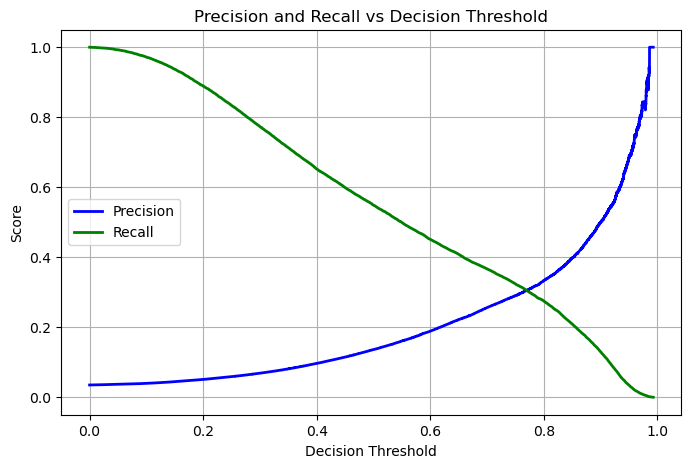

In [16]:
precision, recall, threshold = precision_recall_curve(y_train, cv_proba, pos_label=1)
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

# Precision vs threshold
plt.plot(threshold, precision[:-1], "b-", linewidth=2, label="Precision")

# Recall vs threshold
plt.plot(threshold, recall[:-1], "g-", linewidth=2, label="Recall")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")

plt.legend()
plt.grid(True)

plt.show()